/var/folders/lx/0h760fjj75g65qlknyyvp6y00000gp/T/ipykernel_41243/2652558443.py:51: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node = create_react_agent(llm,tools=tools)


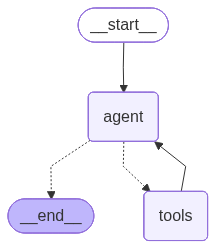

In [9]:
from typing import Annotated,TypedDict,Sequence
from langgraph.graph import StateGraph,START,END
from langchain_openai import OpenAIEmbeddings,ChatOpenAI
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage
from langgraph.graph.message import add_messages
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.tools import Tool


llm = ChatOpenAI(model="gpt-4o-mini")

def make_retriever_astool(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    split_docs = RecursiveCharacterTextSplitter(chunk_size = 500,chunk_overlap=50).split_documents(documents=docs)
    vs = FAISS.from_documents(documents=split_docs,embedding=OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"Using tool {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name,description=desc,func=tool_func)

def wiki_search(query:str):
    api_wrapper = WikipediaAPIWrapper()
    wiki = WikipediaQueryRun(api_wrapper=api_wrapper)
    return wiki.run(query)

Wiki_Tool = Tool(name="Wiki",description="This is used for websearch",func=wiki_search)

def arxiv_search(query:str):
    api_wrapper = ArxivAPIWrapper()
    arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
    return arxiv.run(query)

Arxiv_tool = Tool(name="Arxiv",description="This is useful for websearch",func=arxiv_search)

Internal_Tool1 = make_retriever_astool("internaldocs.txt","Internal_Docs","This is about transformer models")

Internal_Tool2 = make_retriever_astool("internaldocs_2.txt","Internal_Docs2","This is about Agents")

tools = [Arxiv_tool,Wiki_Tool,Internal_Tool1,Internal_Tool2]

from langgraph.prebuilt import create_react_agent

react_node = create_react_agent(llm,tools=tools)

react_node




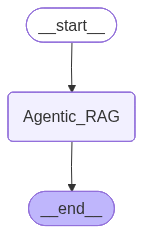

In [10]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage],add_messages]

builder = StateGraph(AgentState)

builder.add_node("Agentic_RAG",react_node)
builder.set_entry_point("Agentic_RAG")
builder.add_edge("Agentic_RAG",END)

graph = builder.compile()

graph


In [11]:
query = "What do our internal research notes say about transformer variants,and what does Arxiv suggest recently"

results = graph.invoke({"messages":[HumanMessage(content=query)]})

print(results["messages"][-1].content)

result = graph.invoke({"messages":[HumanMessage(content=query)]})

print(result["messages"][-1].content)


Using tool Internal_Docs
### Internal Research Notes on Transformer Variants

The transformer architecture, introduced in the paper **"Attention Is All You Need"** by Ashish Vaswani and colleagues, has spurred various transformer variants aimed at enhancing performance, efficiency, and scalability across numerous tasks. Here’s a summary of key transformer variants:

#### Encoder-Based Transformers
- **Purpose**: Process input text to generate contextual representations.
- **Example**: **BERT (Bidirectional Encoder Representations from Transformers)**, developed by Google.
- **Key Features**:
  - Bidirectional context understanding.
  - High performance on classification and question-answering tasks.
  - Pretrained on extensive corpora and fine-tuned for downstream applications.
- **Applications**: 
  - Sentiment analysis.
  - Named entity recognition.
  - Document classification.

#### Decoder-Based Transformers
- **Purpose**: Generate text sequentially, typically for language generati